# Rito de Alinhamento de Projetos — 15/09/2026

Fonte: reunião entre Julio, Jaqueline e Joyce (transcrição de 1h22) + os dois reports de
projeto do dia (AgriManager e myFarm).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

COR_PRIMARIA   = "#0072B2"
COR_SECUNDARIA = "#94A3B8"
COR_DESTAQUE   = "#E69F00"
COR_ALERTA     = "#D55E00"
PALETA = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.prop_cycle": plt.cycler(color=PALETA),
})

## Os dados foram lidos corretamente?

Carregar os dois reports (AgriManager e myFarm) e conferir shape, tipos e head antes de
qualquer análise.

In [2]:
RITO_DIR = "../../Ritos - Projetos/Rito dia 15 de Setembro de 2026"

agm = pd.read_excel(f"{RITO_DIR}/Report Projetos AgriManager 2025-2026 - Report 09-2026.xlsx")
myfarm = pd.read_excel(f"{RITO_DIR}/Report Projetos Myfarm 2025-2026.xlsx")

print(agm.shape, myfarm.shape)
agm.head(3)

(17, 17) (81, 18)


,COD,PROJETO,SISTEMA,TIPO PROJETO,HR ADQ,DT_INICIAL,STATUS,QUALIFICAÇÃO,RESPONSAVEL,GERENTE,PLANEJADO,REALIZADO,ESTOQUE DE HR,FINANCEIRO,FATURADO,"Andamento, previsão de encerramento, status financeiro do projeto, travas e impedimentos",Unnamed: 16
0,30017580,CANINDE GRAOS - ALIANCA DO TOCANTINS - TO IMPL...,SIAGRI AGRIMANAGER,IMPLANTACAO,60.0,2026-09-02,EM ANDAMENTO,SIM,FELIPE DA SILVA VERZOTTO,JAQUELINE NEVES MARTINS,60.0,0.0,60.0,60.0,60.0,Cliente com contrato ativo. Implantação previs...,NaN
1,30017536,GRUPO GERMINA - LUIS EDUARDO MAGALHAES - BA IM...,SIAGRI AGRIMANAGER,IMPLANTACAO,92.0,2026-08-28,EM ANDAMENTO,SIM,FELIPE DA SILVA VERZOTTO,JAQUELINE NEVES MARTINS,92.0,0.0,92.0,92.0,92.0,Cliente com contrato ativo. Implantação previs...,NaN
2,30017544,FAZENDA FERRADURA - PRIMAVERA DO LESTE - MT RE...,SIAGRI AGRIMANAGER,REIMPLANTACAO,120.0,2026-08-07,EM ANDAMENTO,SIM,RHEIDER TELES SILVEIRA,JAQUELINE NEVES MARTINS,32.0,0.0,120.0,120.0,120.0,Cliente com contrato ativo! Inicialmente negoc...,NaN


**Leitura correta.** Números vieram como número (não texto com vírgula), datas como data. AGM
tem 17 linhas (14 projetos + total + linha em branco + rodapé de filtro), myFarm tem 81 (78
projetos + total + rodapé). Vou remover as linhas de total/rodapé antes de seguir.

## Limpar as linhas de total e rodapé, e juntar os dois sistemas

Cada report tem uma linha "Total" e um rodapé de filtro no fim. Remover isso, marcar de qual
sistema/rito veio cada linha, e empilhar os dois num único DataFrame pra facilitar a contagem.

In [3]:
agm_ok = agm[agm["COD"].apply(lambda v: str(v).replace(".0", "").isdigit())].copy()
myfarm_ok = myfarm[myfarm["COD"].apply(lambda v: str(v).replace(".0", "").isdigit())].copy()

agm_ok["ORIGEM"] = "AgriManager"
myfarm_ok["ORIGEM"] = "myFarm"

projetos = pd.concat([agm_ok, myfarm_ok], ignore_index=True)
projetos.shape

(92, 21)

In [4]:
projetos["ORIGEM"].value_counts().to_frame()

,count
ORIGEM,
myFarm,78
AgriManager,14


**14 projetos de AgriManager e 78 de myFarm** entraram nos dois reports do dia — bate com o
que tinha sido extraído linha a linha. Confirmado, dá pra seguir para a pergunta de negócio.

## Quantos projetos estão abertos hoje, e em que situação?

"Aberto" aqui é tudo que não foi cancelado nem concluído — inclui "em andamento" e
"encerramento" (que já tem data de fim definida, só falta formalizar).

In [5]:
status_por_sistema = projetos.groupby(["ORIGEM", "STATUS"]).size().unstack(fill_value=0)
status_por_sistema["Total"] = status_por_sistema.sum(axis=1)
status_por_sistema

STATUS,CANCELADO,CONCLUIDO,EM ANDAMENTO,ENCERRAMENTO,Total
ORIGEM,,,,,
AgriManager,0,2,10,2,14
myFarm,14,0,64,0,78


**76 projetos abertos hoje** (12 AgriManager + 64 myFarm), somando "em andamento" e
"encerramento". Do lado do AgriManager a fila de encerramento já está pequena (2), e mais dois
foram fechados por email na própria hora da reunião. Do lado do myFarm o volume de cancelamento
chama atenção: 14 clientes pediram para cancelar — quase 1 em cada 6 projetos que entraram no
funil (14 de 92 no total, ou 18% olhando só myFarm).

## Quantos desses projetos abertos têm cliente inadimplente ou em risco?

O status "EM ANDAMENTO" não distingue cliente saudável de cliente em atraso — isso só aparece
no texto livre da coluna de observação. Vou marcar quem menciona suspensão por inadimplência.

In [6]:
cols_obs = [c for c in projetos.columns if "impediment" in c.lower()]
projetos["OBS"] = projetos[cols_obs].bfill(axis=1).iloc[:, 0].fillna("")

abertos = projetos[projetos["STATUS"].isin(["EM ANDAMENTO", "ENCERRAMENTO"])].copy()
abertos["INADIMPLENTE"] = abertos["OBS"].str.contains("inadimpl", case=False)

abertos.groupby("ORIGEM")["INADIMPLENTE"].sum().to_frame("projetos c/ cliente inadimplente")

,projetos c/ cliente inadimplente
ORIGEM,
AgriManager,1
myFarm,7


**8 dos 76 projetos abertos (~11%) têm cliente inadimplente** — 1 no AgriManager (Fazenda Bela
Vista) e 7 no myFarm. É uma fatia pequena do total, mas concentra risco: são projetos que não
avançam porque o cliente não paga, não porque falta trabalho da equipe — a alavanca aqui é
cobrança, não consultoria.

## Por que os outros projetos estão parados? (fora a inadimplência)

Não existe uma coluna de "motivo do atraso" pronta — o texto livre da observação é a única
fonte. Vou categorizar por padrões de texto recorrentes que apareceram tanto no report quanto na
transcrição da reunião.

In [7]:
motivos = {
    "Cliente sumiu / não responde":        r"não retorna|sem retorno|não consegu\w+ contato|tentando contato|não respond",
    "Cliente recusa atendimento agora":    r"não quis|não quer|recusou|recusa\b",
    "Dificuldade de agenda do cliente":    r"agenda.{0,25}(?:cheia|atarefad|viagem|campo|complicad|corrid)",
    "Falta só formalizar (handoff/encerramento)": r"handoff|hand off",
    "Cliente inadimplente":                r"inadimpl",
}

for nome, padrao in motivos.items():
    abertos[nome] = abertos["OBS"].str.contains(padrao, case=False, regex=True)

abertos[list(motivos)].sum().sort_values(ascending=False).to_frame("projetos abertos")

,projetos abertos
Falta só formalizar (handoff/encerramento),26
Cliente sumiu / não responde,11
Cliente inadimplente,8
Cliente recusa atendimento agora,2
Dificuldade de agenda do cliente,1


In [8]:
abertos["SEM_MOTIVO_IDENTIFICADO"] = ~abertos[list(motivos)].any(axis=1)
abertos["OBS"].str.contains("conforme cronograma", case=False).sum(), abertos["SEM_MOTIVO_IDENTIFICADO"].sum()

(np.int64(7), np.int64(31))

**O maior motivo não é o cliente — é a casa.** De 76 projetos abertos, 26 (34%) já entregaram o
que o cliente precisava e só falta a equipe preencher o handoff e formalizar o encerramento —
é exatamente o ponto que você cobrou ao vivo na reunião ("status report não é mandar mensagem
no WhatsApp"). Isso é retrabalho administrativo represado, não trabalho pendente de verdade.

Os outros motivos, em ordem: 11 projetos (14%) com cliente sumido ou sem retorno, 8 (11%) com
cliente inadimplente (achado anterior), 2 recusando atendimento agora e 1 travado por agenda do
cliente. Sete dizem textualmente "em andamento conforme cronograma" (saudáveis), e outros 31
(41%) não têm motivo de bloqueio explícito no texto — parte deve estar progredindo normal, mas
o relatório não padroniza isso, então não dá pra afirmar quais.

**Estes números são contagem de menção no texto livre, não uma causa comprovada** — é o que a
própria equipe escreveu sobre o projeto, então reflete o relato dela, não uma auditoria
independente.

## Qual o tamanho financeiro dessa fila?

Saldo financeiro (`FINANCEIRO`) é o que ainda pode ser cobrado/prestado de contas do cliente —
horas de consultoria mais gerenciamento não lançado. Ver o total parado por sistema e por
motivo de bloqueio.

In [9]:
def horas(v):
    return f"{v:,.0f}h".replace(",", ".")

total_financeiro = abertos["FINANCEIRO"].sum()
por_sistema = abertos.groupby("ORIGEM")["FINANCEIRO"].sum()
print("Saldo financeiro total em projetos abertos:", horas(total_financeiro))
por_sistema.apply(horas).to_frame("saldo financeiro")

Saldo financeiro total em projetos abertos: 1.008h


,saldo financeiro
ORIGEM,
AgriManager,695h
myFarm,314h


**~1.008 horas de saldo financeiro estão paradas** nos projetos em aberto — a maior parte
(695h, 69%) no AgriManager, mesmo ele tendo só 12 dos 76 projetos abertos. Isso porque implantação
de AGM é um pacote maior por natureza (essenciais de 70 a 250h) e concentra os casos mais graves
de saldo alto sem uso, como o Grupo Ferrari (95,5h, cliente não quer mais atendimento) e a
Fazenda Bela Vista (48h, cliente inadimplente). No myFarm o saldo médio por projeto é bem menor
(~5h), coerente com pacotes essenciais de 20 a 40h.

Boa parte desse saldo (nos dois sistemas) é hora de gerenciamento de projeto ainda não lançada,
não hora de consultor disponível pro cliente usar — ou seja, é lançamento atrasado, não
capacidade ociosa.

## Gráfico: o que está represando os projetos abertos

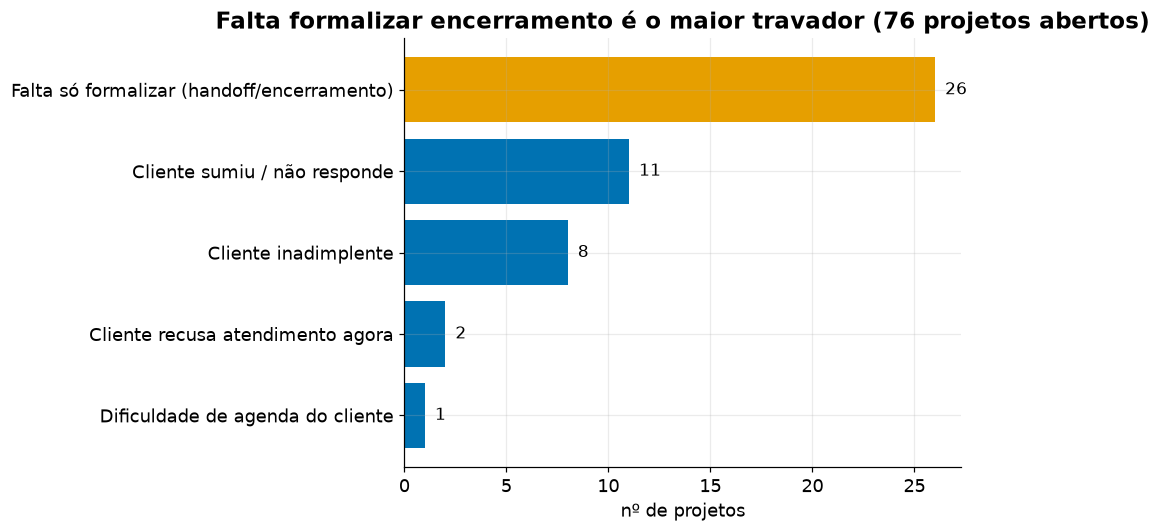

In [10]:
contagem = abertos[list(motivos)].sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
cores = [COR_DESTAQUE if v == contagem.max() else COR_PRIMARIA for v in contagem]
ax.barh(contagem.index, contagem.values, color=cores)
for i, v in enumerate(contagem.values):
    ax.text(v + 0.5, i, str(v), va="center", fontsize=11)
ax.set_title("Falta formalizar encerramento é o maior travador (76 projetos abertos)")
ax.set_xlabel("nº de projetos")
plt.tight_layout()
plt.show()

## E os 14 cancelamentos do myFarm — por que o cliente sai?

Esses já saíram do funil de "aberto", mas explicam parte da pressão em vendas baixas: quanto
o cliente cancela por decisão própria vs. por inadimplência/distrato.

In [11]:
cancelados = projetos[projetos["STATUS"] == "CANCELADO"].copy()
cancelados["POR_CHURN_DISTRATO"] = cancelados["OBS"].str.contains("distrato|churn", case=False)

len(cancelados), int(cancelados["POR_CHURN_DISTRATO"].sum())

(14, 2)

**14 cancelamentos, mas só 2 com o registro formal de CHURN/distrato no sistema.** Os outros 12
aparecem só como "cliente solicitou o cancelamento" no texto — o pedido foi atendido, mas sem
o rastro formal de churn que a Aliare usa pra apurar motivo e taxa de cancelamento. É o mesmo
padrão de disciplina de processo que aparece nos 26 projetos "só falta formalizar": a operação
resolve o problema do cliente, mas não fecha o registro administrativo por trás.

## Resumo desta análise

- **76 projetos abertos hoje** entre os dois sistemas (12 AgriManager, 64 myFarm), de um total
  de 92 no funil do dia. 14 myFarm foram cancelados a pedido do cliente e 2 AgriManager foram
  concluídos hoje mesmo, na própria reunião.
- **O maior travador não é o cliente, é o processo interno**: 34% dos projetos abertos (26 de
  76) já entregaram o que o cliente precisava e só falta handoff + encerramento formal.
- **Inadimplência atinge 11% dos projetos abertos** (8 de 76: 1 AgriManager, 7 myFarm) — trava
  ligada a cobrança, não a consultoria.
- **~1.008 horas de saldo financeiro** estão paradas nos projetos abertos (695h AgriManager,
  314h myFarm), boa parte por gerenciamento de projeto ainda não lançado no sistema.
- **Cancelamento sem rastro formal**: 12 dos 14 cancelamentos do myFarm não têm o registro de
  churn/distrato preenchido, o que compromete a leitura de motivo de cancelamento mais pra
  frente.
- Fica de fora desta planilha o que a Jaqueline citou de cabeça na reunião (67 projetos myFarm
  anteriores a maio, carteira de ~187 clientes com 65 em aberto): são números verbais do dia,
  não bateram exatamente com o corte deste report — provavelmente por causa de um filtro de data
  diferente ou por já refletirem os encerramentos feitos durante a própria reunião.